# Feature Engineering

In [37]:
#%pip install -r ../requirements.txt -q

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [39]:
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

Dataset downloaded to: /Users/angjiayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [40]:
import pandas as pd
import os

csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
print(f'\n')
print("Shape:", df.shape)
print(f'\n')
print(df.head())
print(f'\n')
print(df.info())


Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv


Shape: (6362620, 11)


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0    

In [41]:
import pandas as pd

df = pd.read_csv(csv_file)


Drop unusable columns due to Kaggle rule

In [42]:
df.drop(['oldbalanceOrg', 'newbalanceOrig','newbalanceDest','oldbalanceDest'], axis=1, inplace=True)
df.shape

(6362620, 7)

Raw, dropped data without feature engineering

In [43]:
# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw/dropped_cols", exist_ok=True)

target_dir = "../data/raw/dropped_cols"
full_file_path = os.path.join(target_dir, 'Dataset_dropped_columns.csv')

df.to_csv(full_file_path, index=False)

### Transaction velocity

In [44]:
# Create a 'day' variable
df['day'] = (df['step'] // 24).astype(int)

# daily transaction counts for fraud and non-fraud
fraud_daily = df[df['isFraud'] == 1].groupby('day').size().reset_index(name='fraud_count')
nonfraud_daily = df[df['isFraud'] == 0].groupby('day').size().reset_index(name='nonfraud_count')


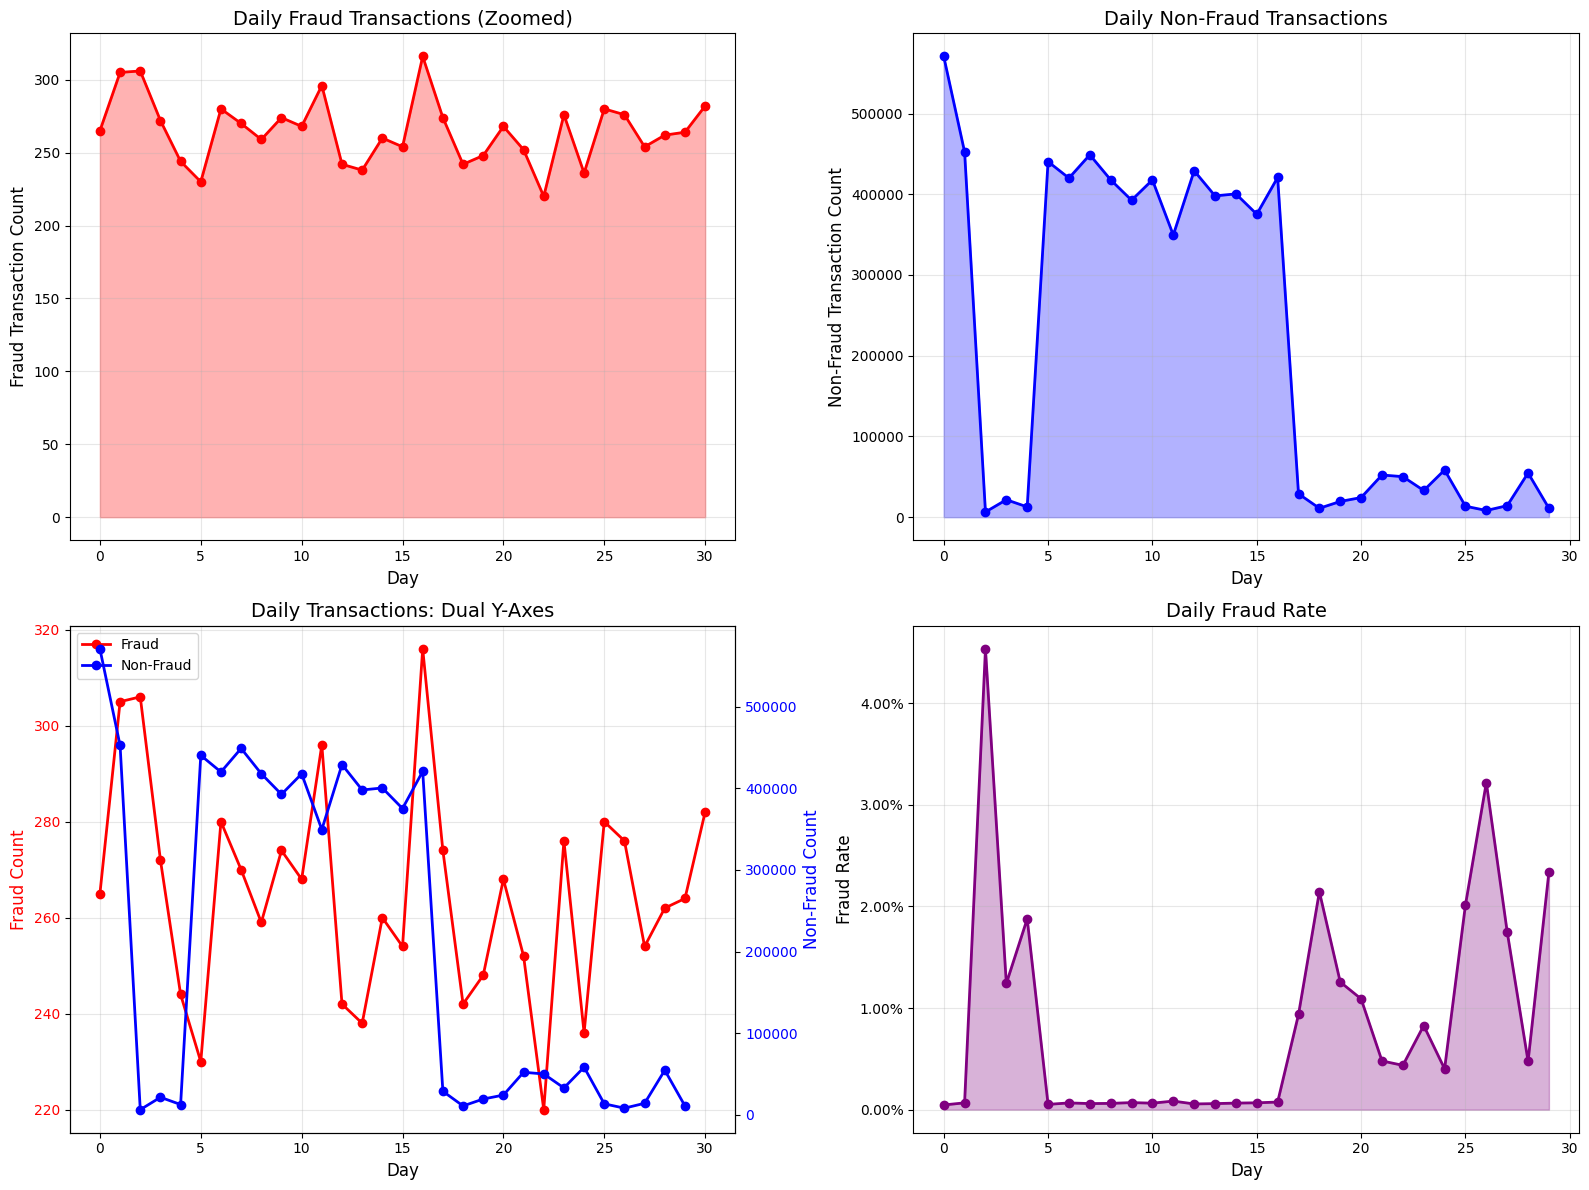

In [45]:
# visualization with dual y-axes to show both fraud and non-fraud clearly
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Fraud only (zoomed in)
axes[0, 0].plot(fraud_daily['day'], fraud_daily['fraud_count'], color='red', marker='o', linewidth=2, markersize=6)
axes[0, 0].fill_between(fraud_daily['day'], fraud_daily['fraud_count'], alpha=0.3, color='red')
axes[0, 0].set_xlabel('Day', fontsize=12)
axes[0, 0].set_ylabel('Fraud Transaction Count', fontsize=12)
axes[0, 0].set_title('Daily Fraud Transactions (Zoomed)', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Non-fraud only
axes[0, 1].plot(nonfraud_daily['day'], nonfraud_daily['nonfraud_count'], color='blue', marker='o', linewidth=2, markersize=6)
axes[0, 1].fill_between(nonfraud_daily['day'], nonfraud_daily['nonfraud_count'], alpha=0.3, color='blue')
axes[0, 1].set_xlabel('Day', fontsize=12)
axes[0, 1].set_ylabel('Non-Fraud Transaction Count', fontsize=12)
axes[0, 1].set_title('Daily Non-Fraud Transactions', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Both with dual y-axes
ax1 = axes[1, 0]
ax2 = ax1.twinx()

line1 = ax1.plot(fraud_daily['day'], fraud_daily['fraud_count'], color='red', marker='o', linewidth=2, markersize=6, label='Fraud')
line2 = ax2.plot(nonfraud_daily['day'], nonfraud_daily['nonfraud_count'], color='blue', marker='o', linewidth=2, markersize=6, label='Non-Fraud')

ax1.set_xlabel('Day', fontsize=12)
ax1.set_ylabel('Fraud Count', fontsize=12, color='red')
ax2.set_ylabel('Non-Fraud Count', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Daily Transactions: Dual Y-Axes', fontsize=14)
ax1.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Plot 4: Fraud rate per day
fraud_rate_daily = fraud_daily.copy()
fraud_rate_daily['total'] = fraud_daily['fraud_count'] + nonfraud_daily['nonfraud_count']
fraud_rate_daily['fraud_rate'] = fraud_daily['fraud_count'] / fraud_rate_daily['total']

axes[1, 1].plot(fraud_rate_daily['day'], fraud_rate_daily['fraud_rate'], color='purple', marker='o', linewidth=2, markersize=6)
axes[1, 1].fill_between(fraud_rate_daily['day'], fraud_rate_daily['fraud_rate'], alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Day', fontsize=12)
axes[1, 1].set_ylabel('Fraud Rate', fontsize=12)
axes[1, 1].set_title('Daily Fraud Rate', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.2%}'.format(y)))

plt.tight_layout()
plt.show()

## nameDest vs amount
This pair explores recipient behavior in terms of the money they receive, uncovering hidden fraud patterns, transaction anomalies, and behavioral clustering among accounts.   


Which recipients (nameDest) receive large or irregular amounts?    
Are there outliers or concentration patterns in how funds are distributed?    
Do fraudulent transactions (if labelled) cluster around certain recipients or amount ranges?    

### Average Amount to Destination
Mean amount transferred to the same receiver (avgAmountToDest)

In [46]:
# Calculate average amount transferred to each receiver per sender
avg_amount_to_dest = (
    df.groupby(['nameOrig', 'nameDest'])['amount']
    .mean()
    .reset_index(name='avgAmountToDest')
)

# Merge back to main dataframe
df = df.merge(avg_amount_to_dest, on=['nameOrig', 'nameDest'], how='left')

print("Average Amount to Destination - Statistics:")
print(df.groupby('isFraud')['avgAmountToDest'].describe())

# Show sample
print("\nSample of avgAmountToDest:")
print(df[['nameOrig', 'nameDest', 'amount', 'avgAmountToDest', 'isFraud']].head(10))

Average Amount to Destination - Statistics:
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  

Sample of avgAmountToDest:
      nameOrig     nameDest    amount  avgAmountToDest  isFraud
0  C1231006815  M1979787155   9839.64          9839.64        0
1  C1666544295  M2044282225   1864.28          1864.28        0
2  C1305486145   C553264065    181.00           181.00        1
3   C840083671    C38997010    181.00           181.00        1
4  C2048537720  M1230701703  11668.14         11668.14        0
5    C90045638   M573487274   7817.71          7817.71        0
6   C154988899   M40806

/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_28014/1836845425.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['isFraud']==0]['avgAmountToDest'].dropna(),


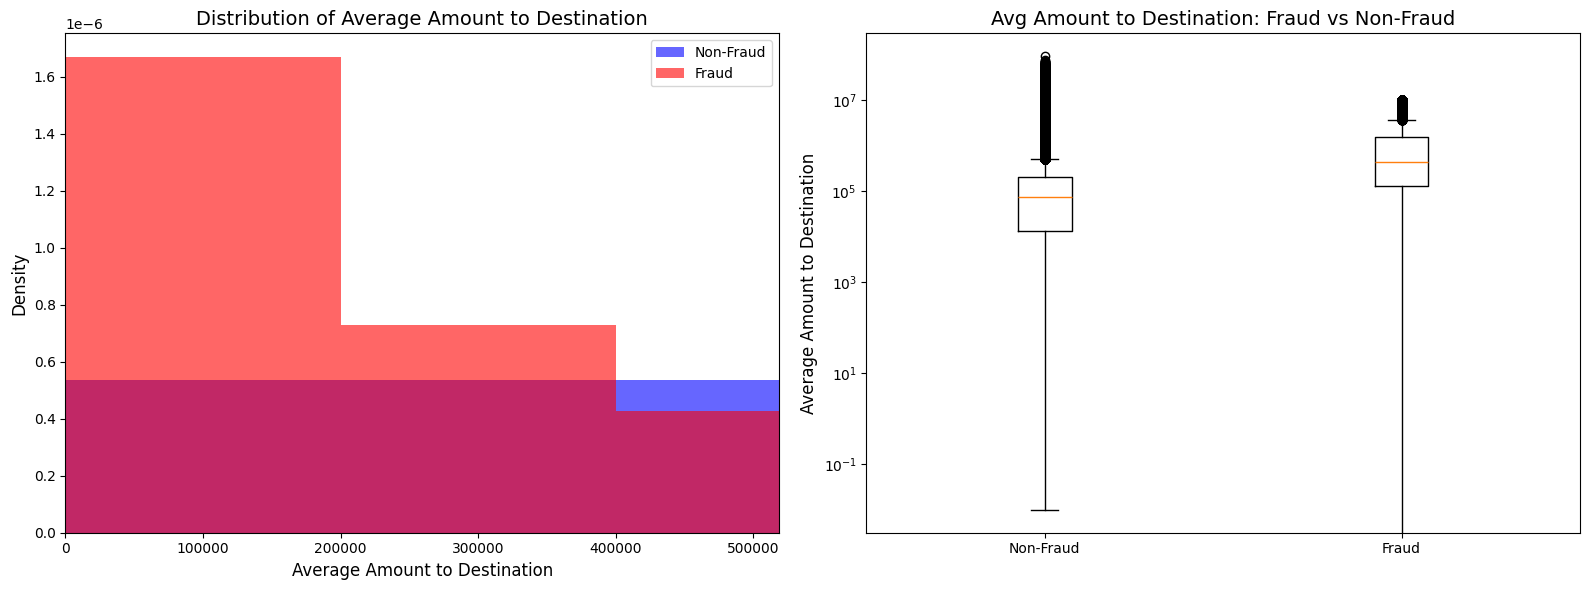

In [47]:
# Visualize average amount to destination
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histogram comparison
axes[0].hist(df[df['isFraud']==0]['avgAmountToDest'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0].hist(df[df['isFraud']==1]['avgAmountToDest'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0].set_xlabel('Average Amount to Destination', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of Average Amount to Destination', fontsize=14)
axes[0].legend()
axes[0].set_xlim(0, df['avgAmountToDest'].quantile(0.95))  # Focus on 95th percentile

# Plot 2: Box plot comparison
axes[1].boxplot([df[df['isFraud']==0]['avgAmountToDest'].dropna(),
                 df[df['isFraud']==1]['avgAmountToDest'].dropna()],
                labels=['Non-Fraud', 'Fraud'])
axes[1].set_ylabel('Average Amount to Destination', fontsize=12)
axes[1].set_title('Avg Amount to Destination: Fraud vs Non-Fraud', fontsize=14)
axes[1].set_yscale('log')  # Log scale due to large range

plt.tight_layout()
plt.show()

Statistics on how much money each receiver typically receives and whether they receive unusually large or small amounts compared to others

In [48]:
# Aggregate statistics per receiver
receiver_amt_stats = (
    df.groupby('nameDest')['amount']
    .agg(['max', 'std'])
    .reset_index()
    .rename(columns={'max':'maxAmountReceived', 'std':'stdAmountReceived'})
)

# Merge back
df = df.merge(receiver_amt_stats, on='nameDest', how='left')

## Top Irregular Receivers (std/mean ratio)
Receivers with high variance relative to their average inflows display unstable financial behavior, a strong laundering or mule signal.

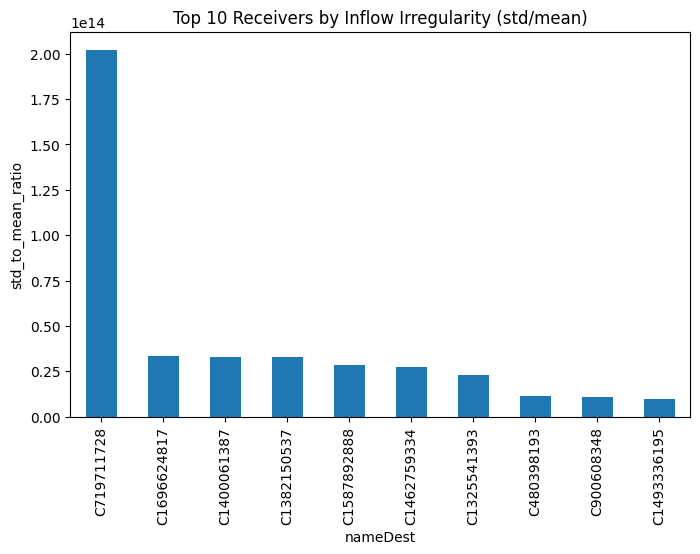

In [49]:
df['std_to_mean_ratio'] = df['stdAmountReceived'] / (df['avgAmountToDest'] + 1e-9)
top_irregular = df.groupby('nameDest')['std_to_mean_ratio'].mean().sort_values(ascending=False).head(10)

top_irregular.plot(kind='bar', figsize=(8,5), title='Top 10 Receivers by Inflow Irregularity (std/mean)')
plt.ylabel('std_to_mean_ratio')
plt.show()

In [50]:
# Get the index (nameDest) of top irregular receivers
irregular_receivers = top_irregular.index.tolist()

# Print each irregular receiver
for receiver in irregular_receivers:
    print(f"Receiver ID: {receiver}")
    
    # Get transactions for this receiver
    receiver_txns = df[df['nameDest'] == receiver]
    
    print(f"Number of transactions: {len(receiver_txns)}")
    print(f"Fraud transactions: {receiver_txns['isFraud'].sum()}")
    print(f"Fraud rate: {(receiver_txns['isFraud'].sum() / len(receiver_txns)) * 100:.2f}%")
    print("-" * 50)

Receiver ID: C719711728
Number of transactions: 6
Fraud transactions: 1
Fraud rate: 16.67%
--------------------------------------------------
Receiver ID: C1696624817
Number of transactions: 8
Fraud transactions: 1
Fraud rate: 12.50%
--------------------------------------------------
Receiver ID: C1400061387
Number of transactions: 3
Fraud transactions: 1
Fraud rate: 33.33%
--------------------------------------------------
Receiver ID: C1382150537
Number of transactions: 3
Fraud transactions: 1
Fraud rate: 33.33%
--------------------------------------------------
Receiver ID: C1587892888
Number of transactions: 4
Fraud transactions: 1
Fraud rate: 25.00%
--------------------------------------------------
Receiver ID: C1462759334
Number of transactions: 3
Fraud transactions: 1
Fraud rate: 33.33%
--------------------------------------------------
Receiver ID: C1382150537
Number of transactions: 3
Fraud transactions: 1
Fraud rate: 33.33%
--------------------------------------------------


## Account Name vs type
This pair describes what kinds of transactions (CASH_OUT, PAYMENT, TRANSFER, etc.) an account usually receives.  


Visualizing this relationship can reveal:       
Dominant transaction types per receiver and their fraud association.

### Heatmap of Accounts vs. Transaction Type
Horizontal lines with multiple strong cells indicate accounts engaged in multiple types — possible laundering intermediaries.

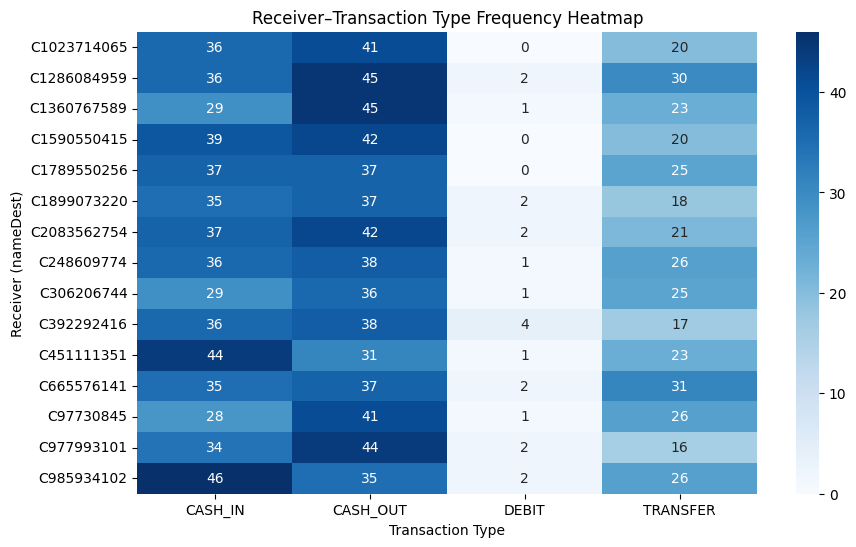

In [51]:
topN = df['nameDest'].value_counts().nlargest(15).index
subset = df[df['nameDest'].isin(topN)]

heatmap_data = pd.crosstab(subset['nameDest'], subset['type'])

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='Blues', annot=True, fmt='d')
plt.title('Receiver–Transaction Type Frequency Heatmap')
plt.xlabel('Transaction Type')
plt.ylabel('Receiver (nameDest)')
plt.show()

## amount vs type
This pair focuses on the monetary behavior of different transaction types.
Understanding how amount distributions vary by type reveals which transaction categories (e.g. CASH_OUT, TRANSFER, PAYMENT) tend to carry larger sums, wider variability, or fraud concentration.    

Which transaction types involve larger or riskier amounts?    
Do some types have tighter distributions, while others vary greatly?     
Is fraud more frequent among high-value types (e.g. TRANSFER, CASH_OUT)?

In [52]:
# Average and percentile per transaction type
type_amt_stats = (
    df.groupby('type')['amount']
    .agg(['mean', lambda x: x.quantile(0.95)])
    .reset_index()
    .rename(columns={'mean':'avgAmountPerType', '<lambda_0>':'p95AmountPerType'})
)

df = df.merge(type_amt_stats, on='type', how='left')

# Ratio and flag
df['amountTypeRatio'] = df['amount'] / (df['avgAmountPerType'] + 1e-9)
df['typeHighValueFlag'] = (df['amount'] > df['p95AmountPerType']).astype(int)

## Mean and Std per Type
Transaction types with both high mean and high std are financially volatile and may be higher risk for fraud.

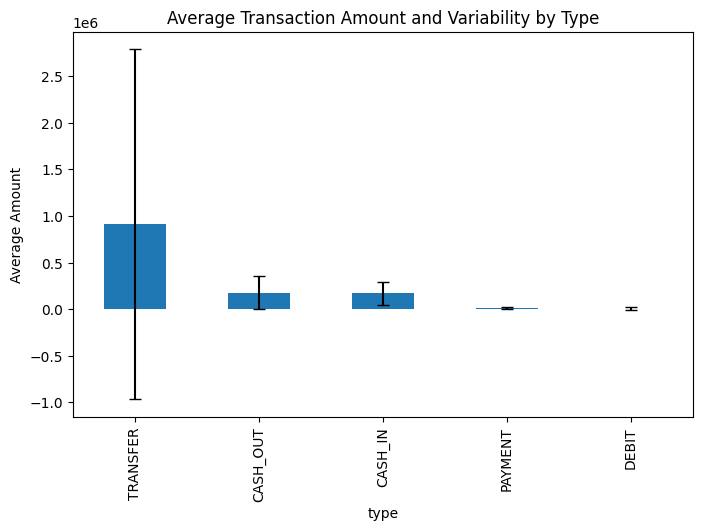

In [53]:
type_summary = df.groupby('type')['amount'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(8,5))
type_summary['mean'].plot(kind='bar', yerr=type_summary['std'], capsize=4)
plt.title('Average Transaction Amount and Variability by Type')
plt.ylabel('Average Amount')
plt.show()

## Strip Plot of Type vs Amount, Colored by Fraud
Fraudulent points (colored) tend to appear at higher amounts within certain types, particularly in TRANSFER or CASH_OUT.

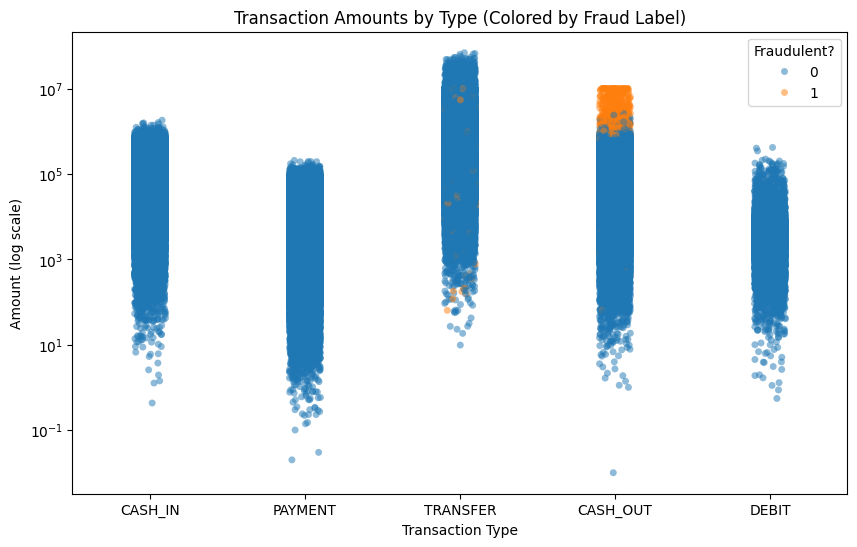

In [54]:
plt.figure(figsize=(10,6))
sns.stripplot(data=df.sample(2000000, random_state=42), x='type', y='amount', hue='isFraud', alpha=0.5)
plt.yscale('log')
plt.title('Transaction Amounts by Type (Colored by Fraud Label)')
plt.xlabel('Transaction Type')
plt.ylabel('Amount (log scale)')
plt.legend(title='Fraudulent?')
plt.show()

## isFraud vs amount
This pair connects monetary value directly with fraudulent behavior.    

How does transaction amount relate to the likelihood of fraud?    
Are fraudulent transactions concentrated in specific amount ranges (e.g., high-value transfers)?    
Can amount-based thresholds or transformations improve fraud detection?

In [55]:
# Log transform
df['amountLog'] = np.log1p(df['amount'])

# Amount binning (e.g., 10 bins)
df['amountBucket'] = pd.qcut(df['amount'], 10, duplicates='drop')

# Fraud probability by bin
fraud_rate_by_bin = df.groupby('amountBucket')['isFraud'].mean().reset_index(name='fraudProbabilityByAmountBin')
df = df.merge(fraud_rate_by_bin, on='amountBucket', how='left')

/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_28014/3253343520.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_bin = df.groupby('amountBucket')['isFraud'].mean().reset_index(name='fraudProbabilityByAmountBin')


### Fraud Rate by Amount Bin

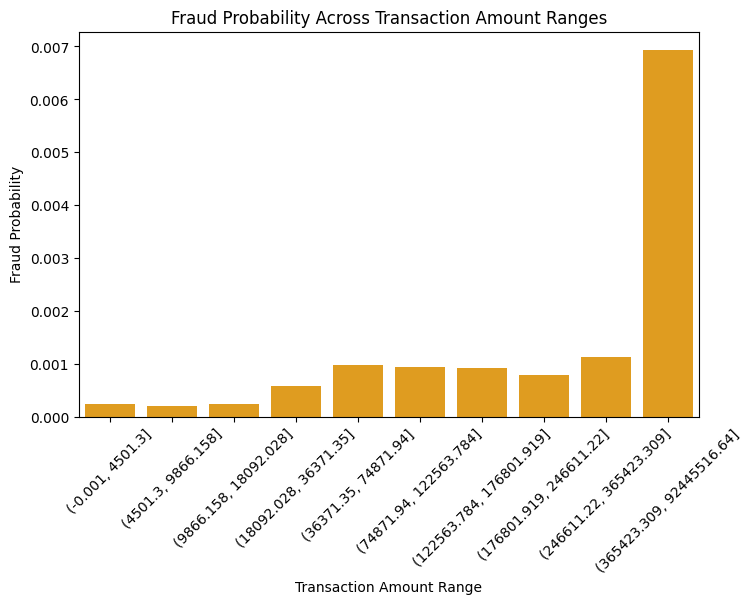

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(data=fraud_rate_by_bin, x='amountBucket', y='fraudProbabilityByAmountBin', color='orange')
plt.title('Fraud Probability Across Transaction Amount Ranges')
plt.xlabel('Transaction Amount Range')
plt.ylabel('Fraud Probability')
plt.xticks(rotation=45)
plt.show()

### Cumulative Fraud Distribution

/Users/angjiayi/code/DSA4263/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


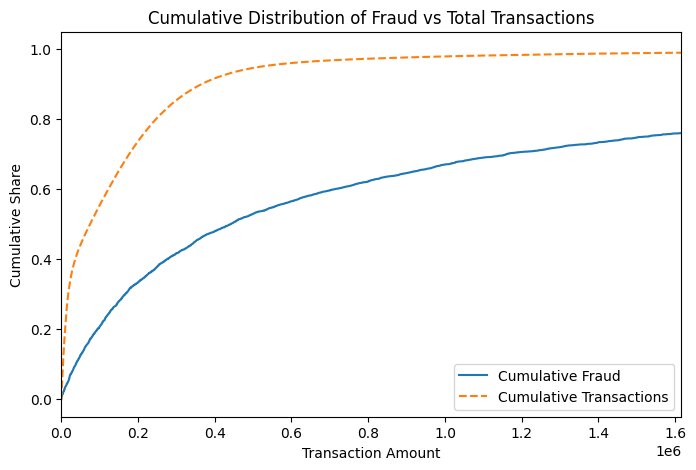

In [57]:
df_sorted = df.sort_values('amount')
cum_fraud = df_sorted['isFraud'].cumsum() / df_sorted['isFraud'].sum()
cum_trans = np.arange(len(df_sorted)) / len(df_sorted)

plt.figure(figsize=(8,5))
plt.plot(df_sorted['amount'], cum_fraud, label='Cumulative Fraud')
plt.plot(df_sorted['amount'], cum_trans, label='Cumulative Transactions', linestyle='--')
plt.title('Cumulative Distribution of Fraud vs Total Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Cumulative Share')
plt.legend()
plt.xlim(0, df['amount'].quantile(0.99))
plt.show()


# Aggregated User Behavior Features

Aggregate statistics per user (nameOrig for senders, nameDest for receivers) to capture overall behavior patterns.

## Sender Aggregations (per nameOrig)

In [58]:
# Calculate sender aggregations
sender_agg = df.groupby('nameOrig').agg({
    'amount': ['sum', 'mean', 'std', 'count'],
    'isFraud': 'max'  # Mark sender as fraud if ANY transaction is fraud
}).reset_index()

# Flatten column names
sender_agg.columns = ['nameOrig', 'totalSent', 'meanSent', 'stdSent', 'numSent', 'sender_has_fraud']

# Calculate fraction of each transaction type per sender
type_fractions = df.groupby(['nameOrig', 'type']).size().unstack(fill_value=0)
type_fractions = type_fractions.div(type_fractions.sum(axis=1), axis=0)
type_fractions.columns = [f'fraction_{col}' for col in type_fractions.columns]
type_fractions = type_fractions.reset_index()

# Merge type fractions with sender aggregations
sender_agg = sender_agg.merge(type_fractions, on='nameOrig', how='left')

print("Sender Aggregation Features:")
print(sender_agg.head(10))
print(f"\nShape: {sender_agg.shape}")
print("\nStatistics by fraud status:")
print(sender_agg.groupby('sender_has_fraud')[['totalSent', 'meanSent', 'stdSent', 'numSent']].describe())

Sender Aggregation Features:
      nameOrig   totalSent    meanSent  stdSent  numSent  sender_has_fraud  \
0  C1000000639   244486.46   244486.46      NaN        1                 0   
1  C1000001337     3170.28     3170.28      NaN        1                 0   
2  C1000001725     8424.74     8424.74      NaN        1                 0   
3  C1000002591   261877.19   261877.19      NaN        1                 0   
4  C1000003372    20528.65    20528.65      NaN        1                 0   
5  C1000003615    49360.77    49360.77      NaN        1                 0   
6  C1000004053   211189.64   211189.64      NaN        1                 0   
7  C1000004530    93865.13    93865.13      NaN        1                 0   
8  C1000005353  3228390.11  3228390.11      NaN        1                 0   
9  C1000005555   233109.79   233109.79      NaN        1                 0   

   fraction_CASH_IN  fraction_CASH_OUT  fraction_DEBIT  fraction_PAYMENT  \
0               0.0                1

## Receiver Aggregations (per nameDest)

In [59]:
# Calculate receiver aggregations
receiver_agg = df.groupby('nameDest').agg({
    'amount': ['sum', 'mean', 'std', 'count'],
    'isFraud': 'max'  # Mark receiver as fraud if ANY transaction is fraud
}).reset_index()

# Flatten column names
receiver_agg.columns = ['nameDest', 'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'receiver_has_fraud']

# Calculate fraction of each transaction type per receiver
type_fractions_recv = df.groupby(['nameDest', 'type']).size().unstack(fill_value=0)
type_fractions_recv = type_fractions_recv.div(type_fractions_recv.sum(axis=1), axis=0)
type_fractions_recv.columns = [f'fraction_{col}_recv' for col in type_fractions_recv.columns]
type_fractions_recv = type_fractions_recv.reset_index()

# Merge type fractions with receiver aggregations
receiver_agg = receiver_agg.merge(type_fractions_recv, on='nameDest', how='left')

print("Receiver Aggregation Features:")
print(receiver_agg.head(10))
print(f"\nShape: {receiver_agg.shape}")
print("\nStatistics by fraud status:")
print(receiver_agg.groupby('receiver_has_fraud')[['totalReceived', 'meanReceived', 'stdReceived', 'numReceived']].describe())

Receiver Aggregation Features:
      nameDest  totalReceived   meanReceived    stdReceived  numReceived  \
0  C1000004082     2259324.39  376554.065000  480874.232699            6   
1  C1000004940     2534004.05  194923.388462  148169.466765           13   
2  C1000013769     6204082.94  477237.149231  558880.114944           13   
3   C100001587     1404313.66  156034.851111  143969.815113            9   
4  C1000015936     2267960.19  141747.511875   78838.151363           16   
5  C1000022185     6394585.48  399661.592500  572471.384128           16   
6  C1000026379      738061.14  184515.285000   62723.609095            4   
7  C1000030947     3511541.23  219471.326875  157501.101319           16   
8   C100003532       47143.23   47143.230000            NaN            1   
9  C1000038153     2891614.02  180725.876250  144776.225962           16   

   receiver_has_fraud  fraction_CASH_IN_recv  fraction_CASH_OUT_recv  \
0                   0               0.500000                

## Merge Aggregations Back to Main DataFrame

In [60]:
# Merge sender aggregations
df = df.merge(sender_agg, on='nameOrig', how='left')

# Merge receiver aggregations
df = df.merge(receiver_agg, on='nameDest', how='left')

print("DataFrame after merging aggregations:")
print(f"Shape: {df.shape}")
print(f"\nNew columns added: {df.shape[1] - len(df.columns) + len(sender_agg.columns) + len(receiver_agg.columns) - 2}")
print("\nSample of new features:")
print(df[['nameOrig', 'nameDest', 'totalSent', 'meanSent', 'numSent', 'totalReceived', 'meanReceived', 'numReceived', 'isFraud']].head(10))

DataFrame after merging aggregations:
Shape: (6362620, 39)

New columns added: 20

Sample of new features:
      nameOrig     nameDest  totalSent  meanSent  numSent  totalReceived  \
0  C1231006815  M1979787155    9839.64   9839.64        1        9839.64   
1  C1666544295  M2044282225    1864.28   1864.28        1        1864.28   
2  C1305486145   C553264065     181.00    181.00        1     9922784.61   
3   C840083671    C38997010     181.00    181.00        1    18017212.53   
4  C2048537720  M1230701703   11668.14  11668.14        1       11668.14   
5    C90045638   M573487274    7817.71   7817.71        1        7817.71   
6   C154988899   M408069119    7107.77   7107.77        1        7107.77   
7  C1912850431   M633326333    7861.64   7861.64        1        7861.64   
8  C1265012928  M1176932104    4024.36   4024.36        1        4024.36   
9   C712410124   C195600860    5337.77   5337.77        1     6062852.98   

    meanReceived  numReceived  isFraud  
0    9839.64000

## Fraud Ratio Among Neighbors

Calculate the percentage of connected accounts (neighbors) that have been involved in fraud.

In [61]:
# For each sender, calculate fraud ratio among receivers they've sent to
sender_neighbor_fraud = df.groupby('nameOrig').agg({
    'nameDest': 'nunique',  # Number of unique receivers
    'receiver_has_fraud': 'sum'  # Number of receivers involved in fraud
}).reset_index()
sender_neighbor_fraud.columns = ['nameOrig', 'num_receivers', 'num_fraud_receivers']
sender_neighbor_fraud['fraudRatioAmongReceivers'] = (
    sender_neighbor_fraud['num_fraud_receivers'] / sender_neighbor_fraud['num_receivers']
)

# For each receiver, calculate fraud ratio among senders they've received from
receiver_neighbor_fraud = df.groupby('nameDest').agg({
    'nameOrig': 'nunique',  # Number of unique senders
    'sender_has_fraud': 'sum'  # Number of senders involved in fraud
}).reset_index()
receiver_neighbor_fraud.columns = ['nameDest', 'num_senders', 'num_fraud_senders']
receiver_neighbor_fraud['fraudRatioAmongSenders'] = (
    receiver_neighbor_fraud['num_fraud_senders'] / receiver_neighbor_fraud['num_senders']
)

# Merge back to main dataframe
df = df.merge(sender_neighbor_fraud[['nameOrig', 'fraudRatioAmongReceivers']], on='nameOrig', how='left')
df = df.merge(receiver_neighbor_fraud[['nameDest', 'fraudRatioAmongSenders']], on='nameDest', how='left')

print("Fraud Ratio Among Neighbors:")
print("\nFor Senders (fraud ratio among their receivers):")
print(df.groupby('isFraud')['fraudRatioAmongReceivers'].describe())
print("\nFor Receivers (fraud ratio among their senders):")
print(df.groupby('isFraud')['fraudRatioAmongSenders'].describe())

Fraud Ratio Among Neighbors:

For Senders (fraud ratio among their receivers):
             count      mean       std  min  25%  50%  75%  max
isFraud                                                        
0        6354407.0  0.009041  0.094592  0.0  0.0  0.0  0.0  1.0
1           8213.0  0.998295  0.029146  0.5  1.0  1.0  1.0  1.0

For Receivers (fraud ratio among their senders):
             count      mean       std       min       25%   50%  75%  max
isFraud                                                                   
0        6354407.0  0.000715  0.010539  0.000000  0.000000  0.00  0.0  1.0
1           8213.0  0.450540  0.402743  0.011236  0.090909  0.25  1.0  1.0
             count      mean       std       min       25%   50%  75%  max
isFraud                                                                   
0        6354407.0  0.000715  0.010539  0.000000  0.000000  0.00  0.0  1.0
1           8213.0  0.450540  0.402743  0.011236  0.090909  0.25  1.0  1.0


## Visualizations: Sender Aggregations

/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_28014/886770374.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])


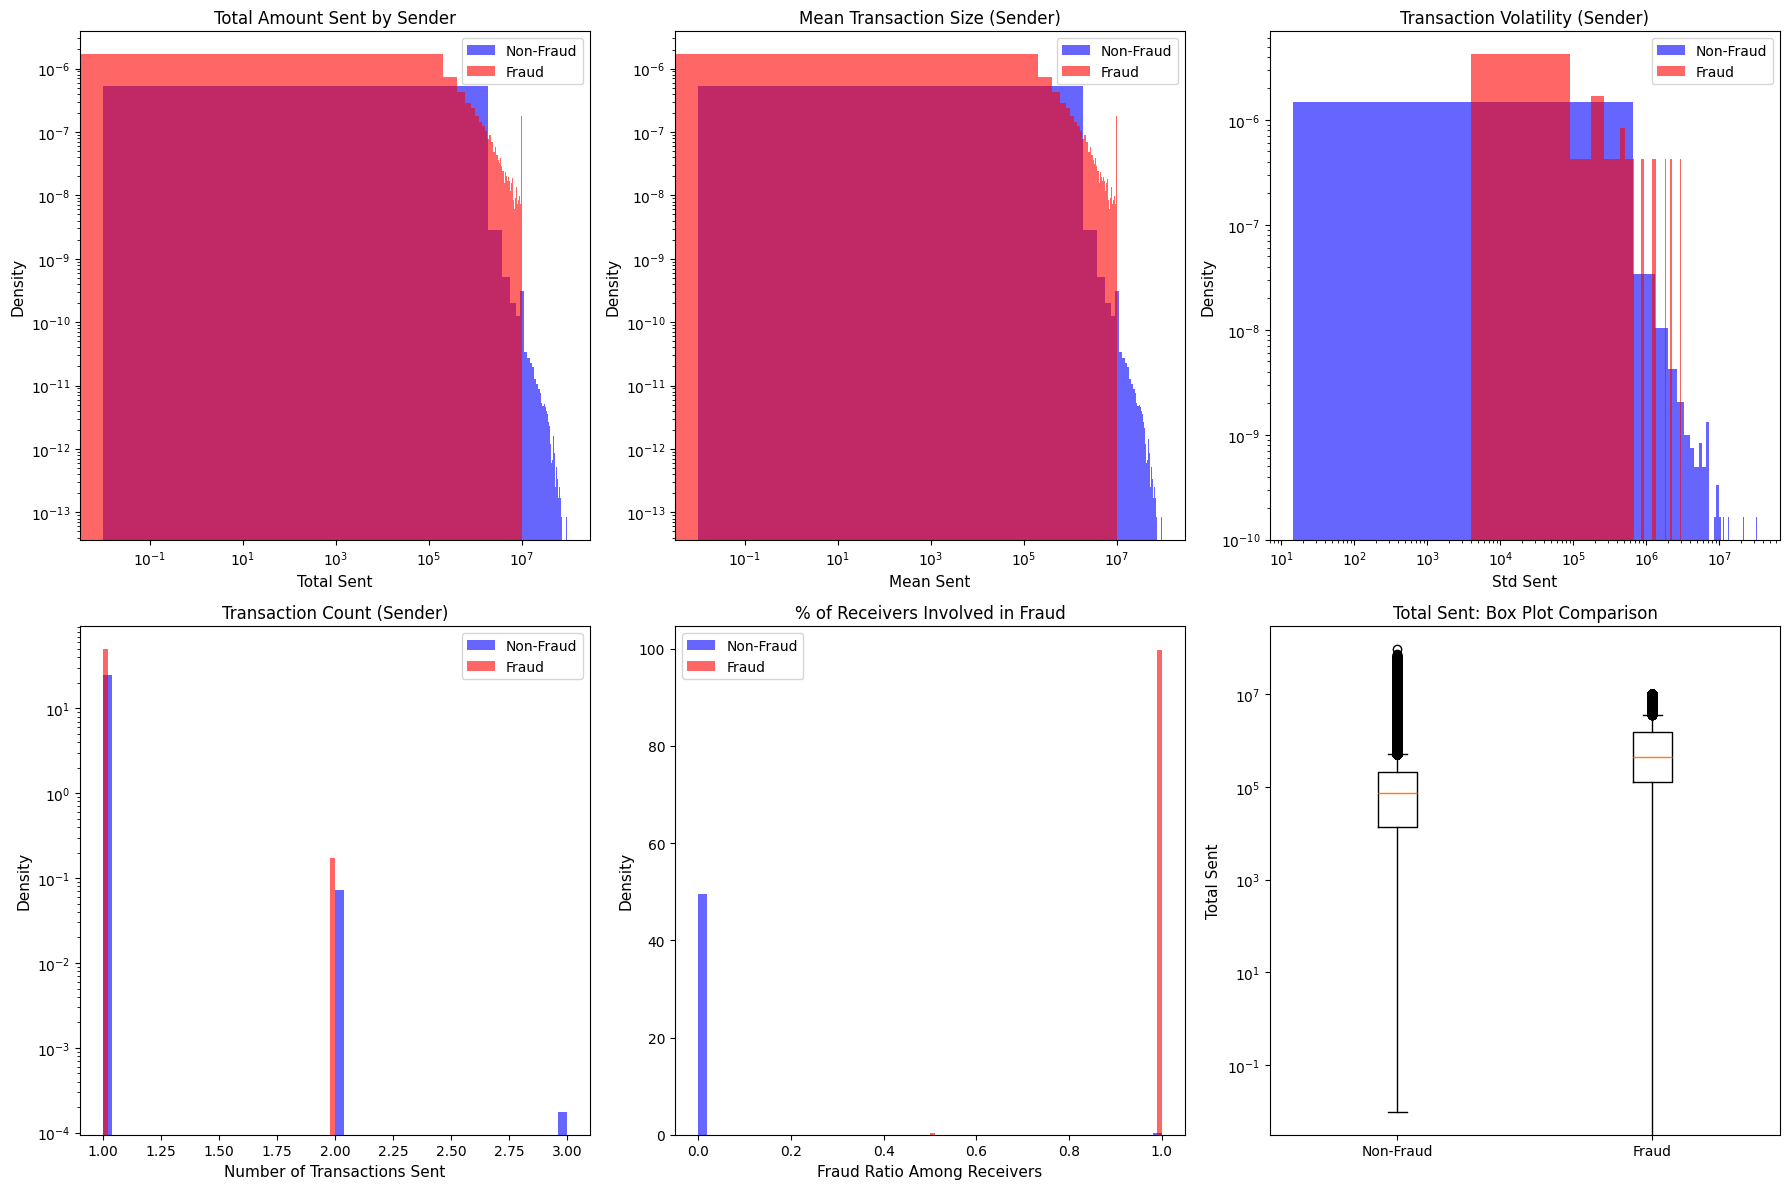

In [62]:
# Visualize sender aggregation features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Total Sent
axes[0, 0].hist(df[df['isFraud']==0]['totalSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 0].hist(df[df['isFraud']==1]['totalSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 0].set_xlabel('Total Sent', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Total Amount Sent by Sender', fontsize=12)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xscale('log')
axes[0, 0].legend()

# Plot 2: Mean Sent
axes[0, 1].hist(df[df['isFraud']==0]['meanSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 1].hist(df[df['isFraud']==1]['meanSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 1].set_xlabel('Mean Sent', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title('Mean Transaction Size (Sender)', fontsize=12)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')
axes[0, 1].legend()

# Plot 3: Std Sent
axes[0, 2].hist(df[df['isFraud']==0]['stdSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 2].hist(df[df['isFraud']==1]['stdSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 2].set_xlabel('Std Sent', fontsize=11)
axes[0, 2].set_ylabel('Density', fontsize=11)
axes[0, 2].set_title('Transaction Volatility (Sender)', fontsize=12)
axes[0, 2].set_yscale('log')
axes[0, 2].set_xscale('log')
axes[0, 2].legend()

# Plot 4: Number of Sent Transactions
axes[1, 0].hist(df[df['isFraud']==0]['numSent'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 0].hist(df[df['isFraud']==1]['numSent'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 0].set_xlabel('Number of Transactions Sent', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Transaction Count (Sender)', fontsize=12)
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Plot 5: Fraud Ratio Among Receivers
axes[1, 1].hist(df[df['isFraud']==0]['fraudRatioAmongReceivers'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 1].hist(df[df['isFraud']==1]['fraudRatioAmongReceivers'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 1].set_xlabel('Fraud Ratio Among Receivers', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('% of Receivers Involved in Fraud', fontsize=12)
axes[1, 1].legend()

# Plot 6: Box plot comparison for totalSent
box_data = [df[df['isFraud']==0]['totalSent'].dropna(),
            df[df['isFraud']==1]['totalSent'].dropna()]
axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])
axes[1, 2].set_ylabel('Total Sent', fontsize=11)
axes[1, 2].set_title('Total Sent: Box Plot Comparison', fontsize=12)
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

## Visualizations: Receiver Aggregations

/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_28014/1303993095.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])


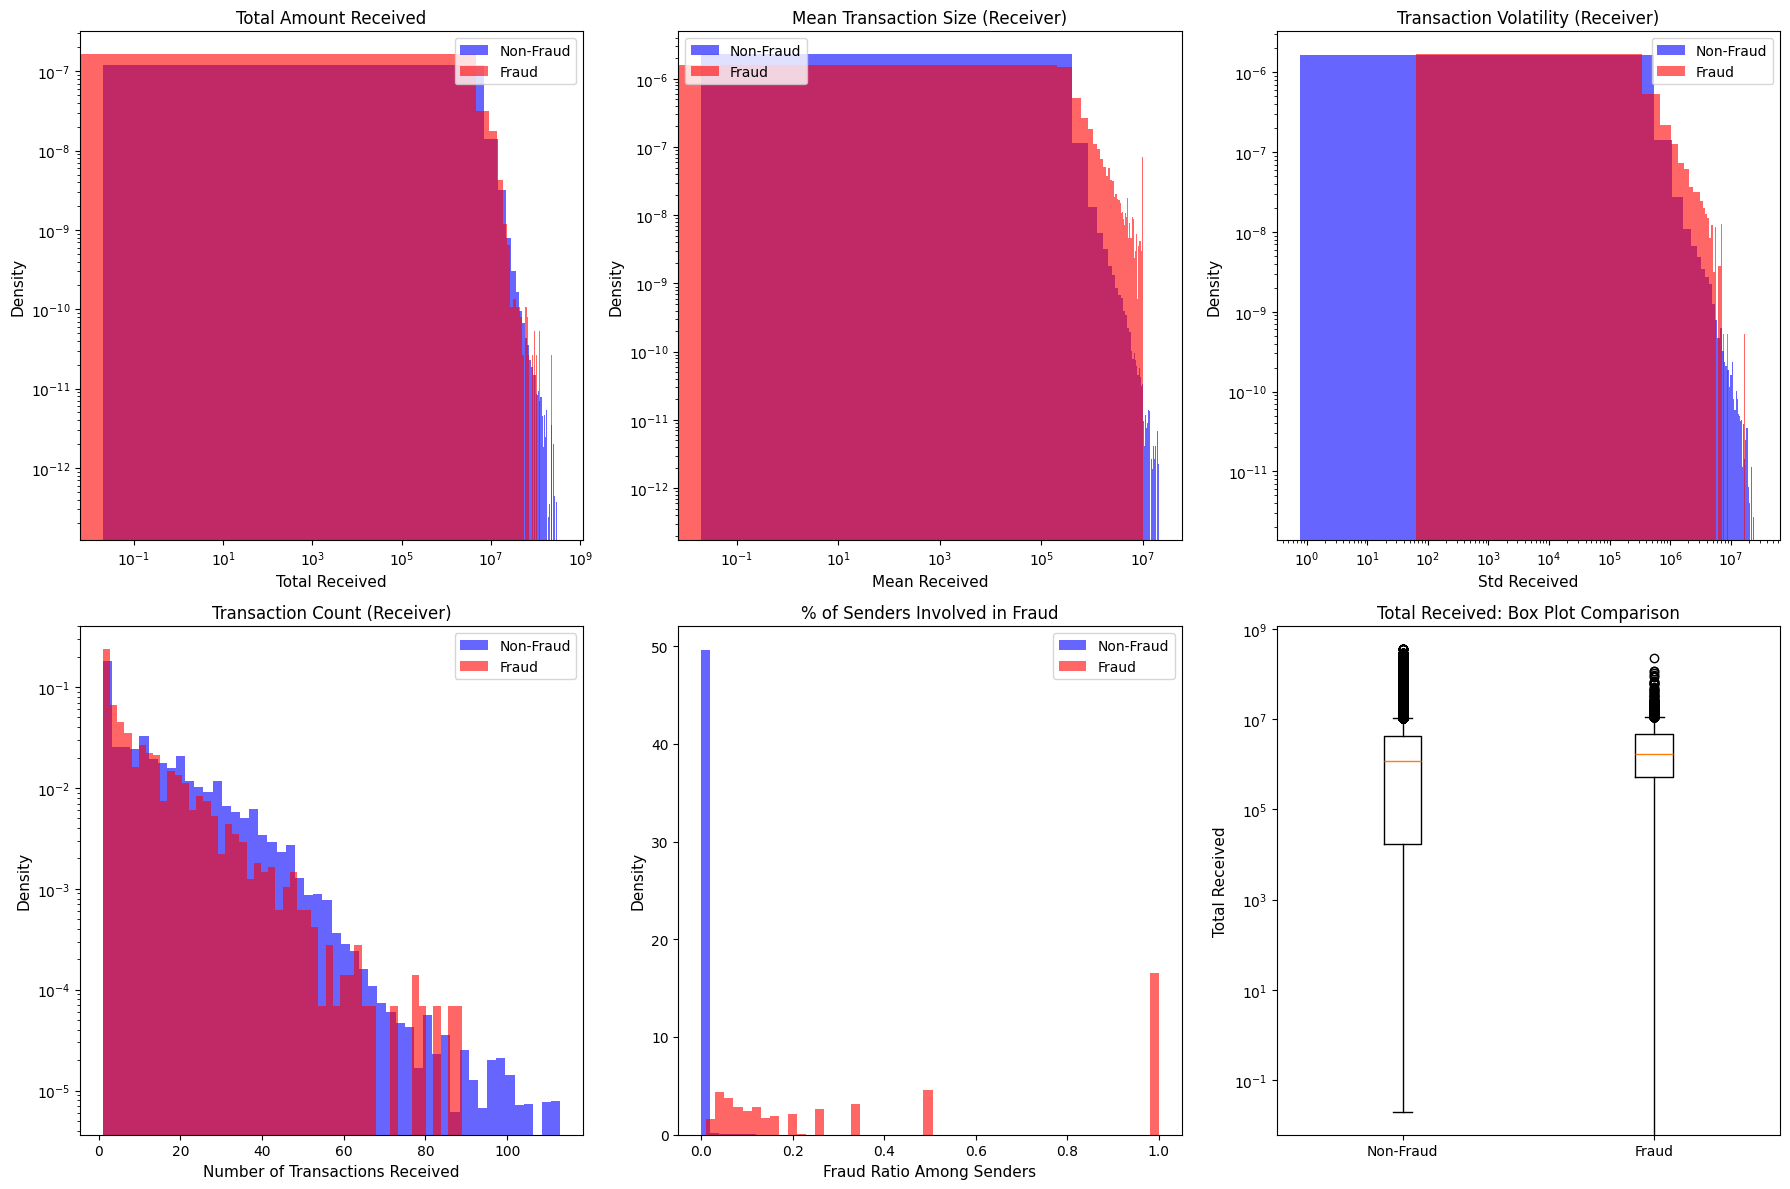

In [63]:
# Visualize receiver aggregation features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Total Received
axes[0, 0].hist(df[df['isFraud']==0]['totalReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 0].hist(df[df['isFraud']==1]['totalReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 0].set_xlabel('Total Received', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Total Amount Received', fontsize=12)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xscale('log')
axes[0, 0].legend()

# Plot 2: Mean Received
axes[0, 1].hist(df[df['isFraud']==0]['meanReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 1].hist(df[df['isFraud']==1]['meanReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 1].set_xlabel('Mean Received', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title('Mean Transaction Size (Receiver)', fontsize=12)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')
axes[0, 1].legend()

# Plot 3: Std Received
axes[0, 2].hist(df[df['isFraud']==0]['stdReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[0, 2].hist(df[df['isFraud']==1]['stdReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[0, 2].set_xlabel('Std Received', fontsize=11)
axes[0, 2].set_ylabel('Density', fontsize=11)
axes[0, 2].set_title('Transaction Volatility (Receiver)', fontsize=12)
axes[0, 2].set_yscale('log')
axes[0, 2].set_xscale('log')
axes[0, 2].legend()

# Plot 4: Number of Received Transactions
axes[1, 0].hist(df[df['isFraud']==0]['numReceived'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 0].hist(df[df['isFraud']==1]['numReceived'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 0].set_xlabel('Number of Transactions Received', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Transaction Count (Receiver)', fontsize=12)
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Plot 5: Fraud Ratio Among Senders
axes[1, 1].hist(df[df['isFraud']==0]['fraudRatioAmongSenders'].dropna(), bins=50, alpha=0.6, label='Non-Fraud', color='blue', density=True)
axes[1, 1].hist(df[df['isFraud']==1]['fraudRatioAmongSenders'].dropna(), bins=50, alpha=0.6, label='Fraud', color='red', density=True)
axes[1, 1].set_xlabel('Fraud Ratio Among Senders', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('% of Senders Involved in Fraud', fontsize=12)
axes[1, 1].legend()

# Plot 6: Box plot comparison for totalReceived
box_data = [df[df['isFraud']==0]['totalReceived'].dropna(),
            df[df['isFraud']==1]['totalReceived'].dropna()]
axes[1, 2].boxplot(box_data, labels=['Non-Fraud', 'Fraud'])
axes[1, 2].set_ylabel('Total Received', fontsize=11)
axes[1, 2].set_title('Total Received: Box Plot Comparison', fontsize=12)
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

## Visualizations: Transaction Type Fractions

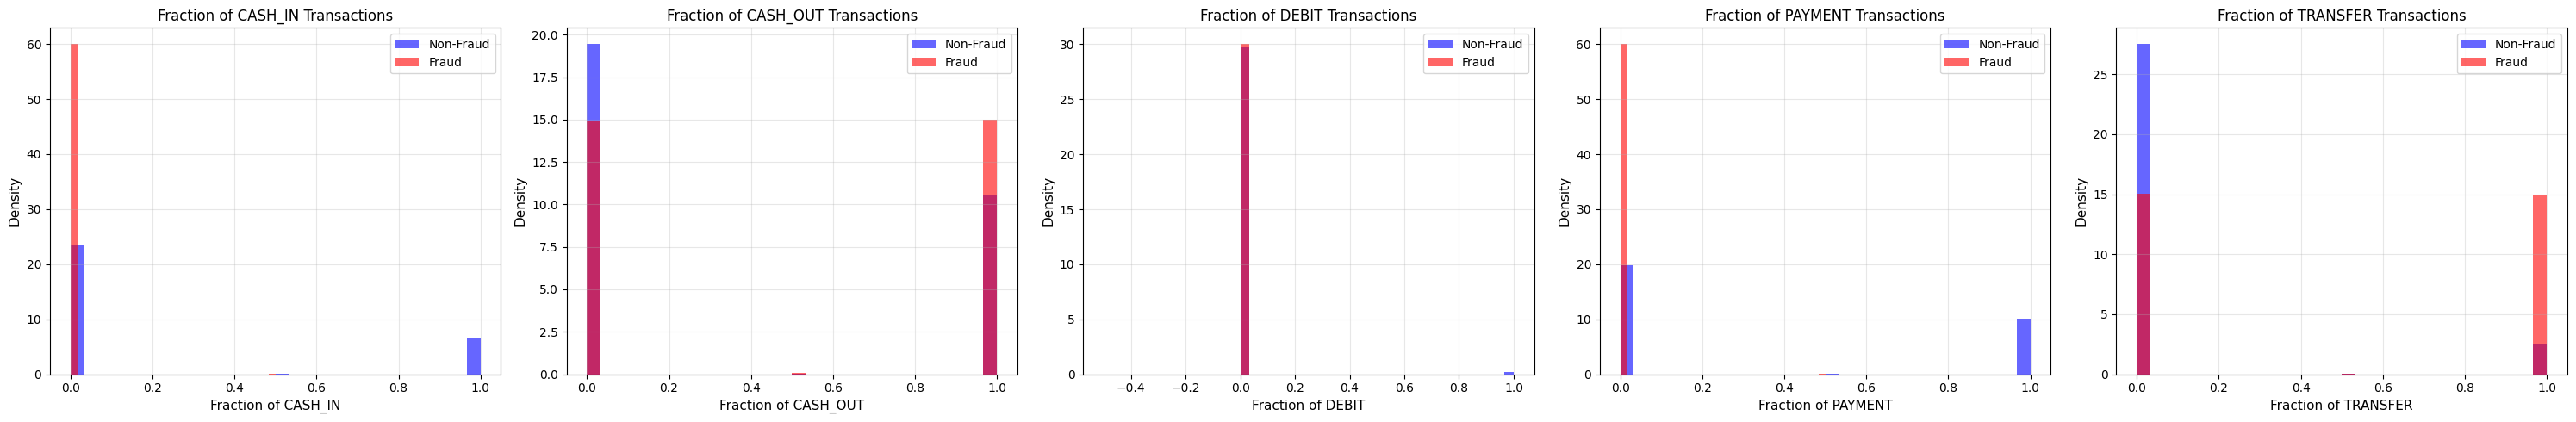

In [64]:
# Visualize transaction type fractions
# Get fraction columns
fraction_cols = [col for col in df.columns if col.startswith('fraction_') and not col.endswith('_recv')]

if len(fraction_cols) > 0:
    fig, axes = plt.subplots(1, len(fraction_cols), figsize=(6*len(fraction_cols), 5))

    if len(fraction_cols) == 1:
        axes = [axes]

    for idx, col in enumerate(fraction_cols):
        # Extract transaction type name
        txn_type = col.replace('fraction_', '')

        # Plot histogram
        axes[idx].hist(df[df['isFraud']==0][col].dropna(), bins=30, alpha=0.6, label='Non-Fraud', color='blue', density=True)
        axes[idx].hist(df[df['isFraud']==1][col].dropna(), bins=30, alpha=0.6, label='Fraud', color='red', density=True)
        axes[idx].set_xlabel(f'Fraction of {txn_type}', fontsize=11)
        axes[idx].set_ylabel('Density', fontsize=11)
        axes[idx].set_title(f'Fraction of {txn_type} Transactions', fontsize=12)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No transaction type fraction columns found")

## Time-based Feature Engineering: hourOfDay and dayOfWeek

In [65]:
#already have df['day'] = df['step']//24,
df['hourOfDay'] = df['step'] % 24
df['dayOfWeek'] = (df['step'] // 24) % 7

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['dayOfWeekName'] = df['dayOfWeek'].map({i:day_labels[i] for i in range(7)})

print("Sample of step → hourOfDay, dayOfWeek, dayOfWeekName:")
display(df[['step','hourOfDay','dayOfWeek','dayOfWeekName']].head(10))


Sample of step → hourOfDay, dayOfWeek, dayOfWeekName:


,step,hourOfDay,dayOfWeek,dayOfWeekName
0,1,1,0,Mon
1,1,1,0,Mon
2,1,1,0,Mon
3,1,1,0,Mon
4,1,1,0,Mon
5,1,1,0,Mon
6,1,1,0,Mon
7,1,1,0,Mon
8,1,1,0,Mon
9,1,1,0,Mon


## Visualizations: Time-based trends

Fraud Rate by Hour of Day (normalised for transaction volume)

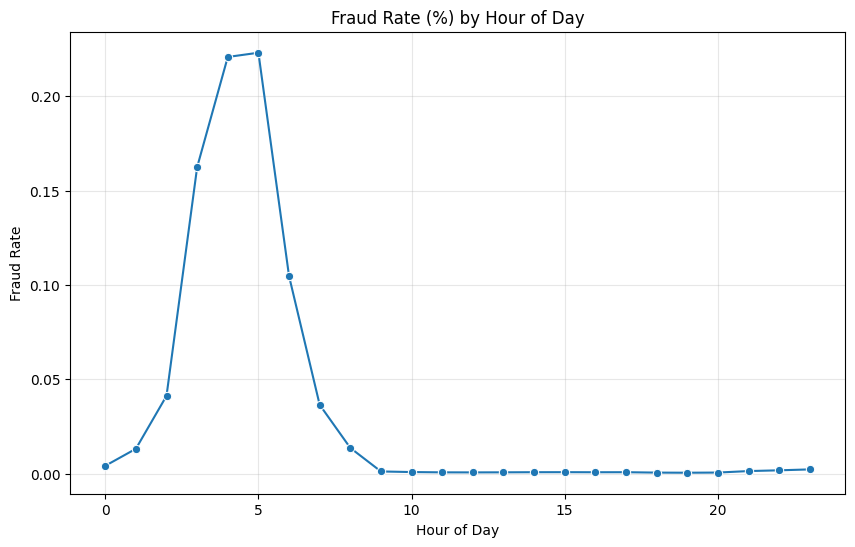

In [66]:
fraud_rate_hour = df.groupby('hourOfDay')['isFraud'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=fraud_rate_hour, x='hourOfDay', y='isFraud', marker='o')
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.grid(True, alpha=0.3)
plt.show()


Fraud Rate by Day of Week

/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_28014/610136244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_rate_day, x='dayOfWeekName', y='isFraud', palette='magma', order=day_order)


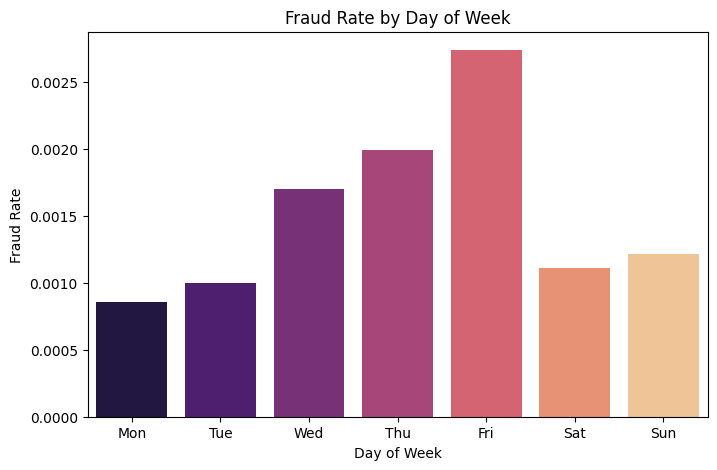

In [67]:
fraud_rate_day = df.groupby('dayOfWeekName')['isFraud'].mean().reset_index()

# enforce weekday ordering
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fraud_rate_day['dayOfWeekName'] = pd.Categorical(fraud_rate_day['dayOfWeekName'],
                                                 categories=day_order, ordered=True)
fraud_rate_day = fraud_rate_day.sort_values('dayOfWeekName')

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_rate_day, x='dayOfWeekName', y='isFraud', palette='magma', order=day_order)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate')
plt.show()

Heatmap of Fraud Rate by Day + Hour

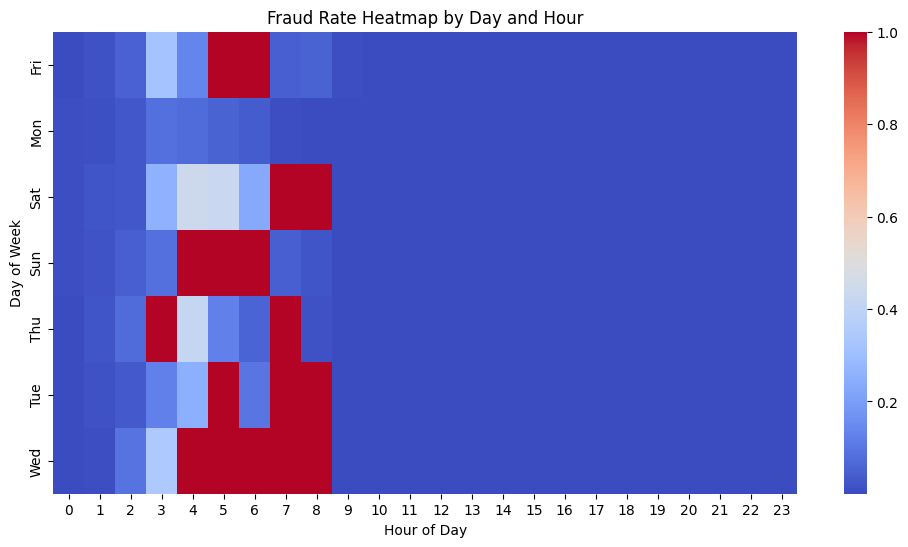

In [68]:
fraud_pivot = df.pivot_table(
    index='dayOfWeekName',
    columns='hourOfDay',
    values='isFraud',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(fraud_pivot, cmap='coolwarm', annot=False)
plt.title('Fraud Rate Heatmap by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()


Identify accounts appearing both as nameOrig and nameDest

In [69]:
senders = set(df['nameOrig'].unique())
receivers = set(df['nameDest'].unique())


overlap_accounts = senders.intersection(receivers)

print(f"Total unique senders: {len(senders)}")
print(f"Total unique receivers: {len(receivers)}")
print(f"Accounts appearing as both sender and receiver: {len(overlap_accounts)}")
print(f'\n')


suspicious_df = df[df['nameOrig'].isin(overlap_accounts) | df['nameDest'].isin(overlap_accounts)]

Total unique senders: 6353307
Total unique receivers: 2722362
Accounts appearing as both sender and receiver: 1769




Rate of transactions involve overlapping accounts

In [70]:
total_txn = df.shape[0]
overlap_txn = suspicious_df.shape[0]
print(f"Percentage of transactions involving dual-role accounts: {(overlap_txn / total_txn) * 100:.2f}%")

# Fraud rate among overlapping accounts
fraud_overlap = suspicious_df['isFraud'].sum()
fraud_rate_overlap = fraud_overlap / suspicious_df.shape[0]
overall_fraud_rate = df['isFraud'].mean()

print(f"Fraud rate (overlap accounts): {fraud_rate_overlap:.4f}")
print(f"Overall fraud rate (entire dataset): {overall_fraud_rate:.4f}")

Percentage of transactions involving dual-role accounts: 0.24%
Fraud rate (overlap accounts): 0.0012
Overall fraud rate (entire dataset): 0.0013


In [71]:
suspicious_df['type'].value_counts()

type
CASH_OUT    7693
CASH_IN     4822
TRANSFER    1807
PAYMENT      618
DEBIT        138
Name: count, dtype: int64

In [ ]:
i = suspicious_df

# Print each account involved in Fraud
for customer in i['nameOrig']:    
    # Get transactions for the account
    # receiver_txns = df[df['nameOrig'] == customer | df['nameDest'] == customer]
    as_sender = df[df['nameOrig'] == customer]
    as_receiver = df[df['nameDest'] == customer]


    all_txns = pd.concat([as_sender,as_receiver])
    if all_txns['isFraud'].sum() == 0:
        continue
    
    print(f"Account ID: {customer}")
    print(f"Number of transactions: {len(all_txns)}")
    print(f"Fraud transactions: {all_txns['isFraud'].sum()}")
    print(f"Fraud rate: {(all_txns['isFraud'].sum() / len(all_txns)) * 100:.2f}%")
    print("-" * 50)

Account ID: C1774310379
Number of transactions: 13
Fraud transactions: 1
Fraud rate: 7.69%
--------------------------------------------------
Account ID: C1496808239
Number of transactions: 1
Fraud transactions: 1
Fraud rate: 100.00%
--------------------------------------------------
Account ID: C2086292862
Number of transactions: 2
Fraud transactions: 1
Fraud rate: 50.00%
--------------------------------------------------
Account ID: C1829721095
Number of transactions: 1
Fraud transactions: 1
Fraud rate: 100.00%
--------------------------------------------------
Account ID: C1175896731
Number of transactions: 1
Fraud transactions: 1
Fraud rate: 100.00%
--------------------------------------------------
Account ID: C145966586
Number of transactions: 1
Fraud transactions: 1
Fraud rate: 100.00%
--------------------------------------------------
Account ID: C1003023037
Number of transactions: 1
Fraud transactions: 1
Fraud rate: 100.00%
--------------------------------------------------
Ac

Number of transactions sent and received by each Account

In [ ]:
# Count number of transactions each user has sent
num_sent = df.groupby('nameOrig').size().reset_index(name='numSent')

# Count number of transactions each user has received
num_received = df.groupby('nameDest').size().reset_index(name='numReceived')

# Merge 'numSent' into main df
df = df.merge(num_sent, on='nameOrig', how='left')

# Merge 'numReceived' into main df
df = df.merge(num_received, on='nameDest', how='left')

# Fill NaN (e.g., users who never received anything) with 0
df[['numSent', 'numReceived']] = df[['numSent', 'numReceived']].fillna(0)


In-Degree and Out-Degree for each Account

In [ ]:
num_unique_dest = (
    df.groupby('nameOrig')['nameDest']
      .nunique()
      .reset_index(name='numUniqueDest')
)

num_unique_orig = (
    df.groupby('nameDest')['nameOrig']
      .nunique()
      .reset_index(name='numUniqueOrig')
)

# Merge sender-based feature
df = df.merge(num_unique_dest, on='nameOrig', how='left')

# Merge receiver-based feature
df = df.merge(num_unique_orig, on='nameDest', how='left')

# Fill missing values (e.g., accounts that never sent or never received)
df[['numUniqueDest', 'numUniqueOrig']] = df[['numUniqueDest', 'numUniqueOrig']].fillna(0)

Transanction Recency: Steps since last transaction by nameOrig

In [ ]:
df = df.sort_values(by=['nameOrig', 'step']).reset_index(drop=True)

df['transactionRecency'] = df.groupby('nameOrig')['step'].diff()

df['transactionRecency'] = df['transactionRecency'].fillna(df['step'])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

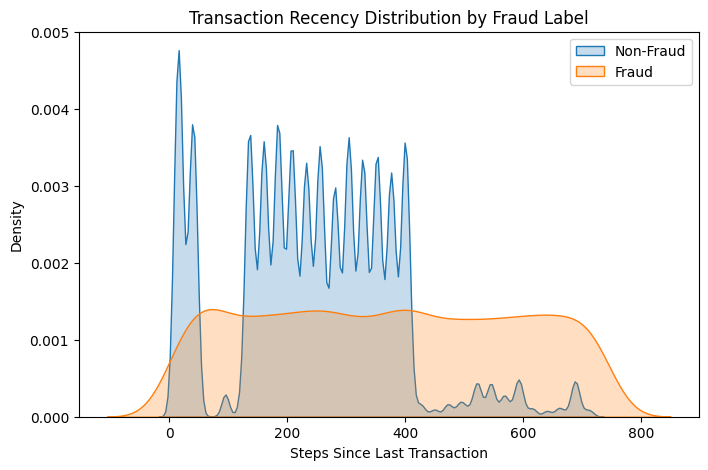

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(df[df['isFraud']==0]['transactionRecency'], label='Non-Fraud', fill=True)
sns.kdeplot(df[df['isFraud']==1]['transactionRecency'], label='Fraud', fill=True)
plt.title('Transaction Recency Distribution by Fraud Label')
plt.xlabel('Steps Since Last Transaction')
plt.legend()
plt.show()

This temporal irregularity suggests that fraudulent accounts often remain dormant for extended periods before executing a burst of activity, consistent with account takeover or mule activation behavior. The contrast in recency profiles underscores the value of temporal features in differentiating legitimate from fraudulent patterns, with low and stable recency associated with normal usage, and high or highly variable recency serving as a potential anomaly indicator.

### Transaction Type Sequence
Encoding of last N transaction types by `nameOrig` (e.g., "CASH-IN → TRANSFER → CASH-OUT")     
- Fraud follows predictable patterns: cash-in to load funds, transfer to move them, cash-out to extract.

In [ ]:
def create_transaction_sequence_features_efficient(df, n_last_transactions):
    # Sort by customer and time
    df = df.sort_values(['nameOrig', 'step']).reset_index(drop=True)
    
    # Create lagged transaction types
    for i in range(1, n_last_transactions + 1):
        df[f'prev_type_{i}'] = df.groupby('nameOrig')['type'].shift(i)
    
    # Create sequence string
    sequence_cols = [f'prev_type_{i}' for i in range(n_last_transactions, 0, -1)] + ['type']
    df['transaction_sequence'] = df[sequence_cols].apply(
        lambda x: '→'.join([str(t) if pd.notna(t) else 'START' for t in x]), 
        axis=1
    )
    
    # Frequency encoding for sequences
    sequence_freq = df['transaction_sequence'].value_counts(normalize=True).to_dict()
    df['sequence_frequency'] = df['transaction_sequence'].map(sequence_freq)
    
    # Flag specific fraud patterns (binary features - memory efficient)
    df['is_cashin_transfer_cashout'] = (
        (df['prev_type_2'] == 'CASH_IN') & 
        (df['prev_type_1'] == 'TRANSFER') & 
        (df['type'] == 'CASH_OUT')
    ).astype(int)
    
    df['is_transfer_cashout'] = (
        (df['prev_type_1'] == 'TRANSFER') & 
        (df['type'] == 'CASH_OUT')
    ).astype(int)

    df['is_cashin_transfer'] = (
        (df['prev_type_1'] == 'CASH_IN') & 
        (df['type'] == 'TRANSFER')
    ).astype(int)
    
    df['is_cashout_transfer'] = (
        (df['prev_type_1'] == 'CASH_OUT') & 
        (df['type'] == 'TRANSFER')
    ).astype(int)  # 9x higher fraud rate!
    
    df['is_transfer_transfer'] = (
        (df['prev_type_1'] == 'TRANSFER') & 
        (df['type'] == 'TRANSFER')
    ).astype(int)  # 8x higher fraud rate!
    
    df['is_first_transfer'] = (
        (df['prev_type_1'] == 'START') & 
        (df['type'] == 'TRANSFER')
    ).astype(int)  # 4x higher fraud rate
    
    df['is_cashin_cashout'] = (
        (df['prev_type_1'] == 'CASH_IN') & 
        (df['type'] == 'CASH_OUT')
    ).astype(int)  # 4x higher fraud rate
    

    df['is_early_transaction'] = (
        (df['prev_type_2'] == 'START') | 
        (df['prev_type_3'] == 'START')
    ).astype(int)
    
    # Label encode previous transaction types (instead of one-hot)
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    
    for i in range(1, n_last_transactions + 1):
        col_name = f'prev_type_{i}'
        df[f'{col_name}_encoded'] = le.fit_transform(df[col_name].fillna('NONE'))
    
    # Count sequence repetitions
    df['sequence_count'] = df.groupby(['nameOrig', 'transaction_sequence']).cumcount() + 1
    
    # # Drop the string columns to save memory (keep encoded versions)
    # df = df.drop([f'prev_type_{i}' for i in range(1, n_last_transactions + 1)], axis=1)
    # df = df.drop('transaction_sequence', axis=1)
    
    return df


# Apply the efficient function
df_with_sequences = create_transaction_sequence_features_efficient(df, n_last_transactions=5)

In [ ]:
df = df_with_sequences

# Analyze fraud patterns in your data
fraud_patterns = df[df['isFraud'] == 1].groupby('transaction_sequence').size().sort_values(ascending=False)
legit_patterns = df[df['isFraud'] == 0].groupby('transaction_sequence').size().sort_values(ascending=False)

print("Top 10 Fraud Sequences:")
print(fraud_patterns.head(10))

print("\nTop 10 Legitimate Sequences:")
print(legit_patterns.head(10))

# Calculate fraud rate by sequence
sequence_fraud_rate = df.groupby('transaction_sequence').agg({
    'isFraud': ['sum', 'count', 'mean']
}).round(4)
sequence_fraud_rate.columns = ['fraud_count', 'total_count', 'fraud_rate']
sequence_fraud_rate = sequence_fraud_rate.sort_values('fraud_rate', ascending=False)

print("\nSequences with highest fraud rates:")
print(sequence_fraud_rate.head(15))

Top 10 Fraud Sequences:
transaction_sequence
START→START→START→START→START→CASH_OUT       4105
START→START→START→START→START→TRANSFER       4090
START→START→START→START→CASH_IN→CASH_OUT        5
START→START→START→START→CASH_OUT→TRANSFER       5
START→START→START→START→CASH_OUT→CASH_OUT       3
START→START→START→START→PAYMENT→CASH_OUT        2
START→START→START→START→PAYMENT→TRANSFER        1
START→START→START→START→TRANSFER→CASH_OUT       1
START→START→START→START→TRANSFER→TRANSFER       1
dtype: int64

Top 10 Legitimate Sequences:
transaction_sequence
START→START→START→START→START→CASH_OUT       2230154
START→START→START→START→START→PAYMENT        2148333
START→START→START→START→START→CASH_IN        1397218
START→START→START→START→START→TRANSFER        528034
START→START→START→START→START→DEBIT            41373
START→START→START→START→CASH_OUT→CASH_OUT       1137
START→START→START→START→CASH_OUT→PAYMENT        1121
START→START→START→START→PAYMENT→CASH_OUT        1095
START→START→START

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'isFlaggedFraud', 'day', 'avgAmountToDest', 'maxAmountReceived',
       'stdAmountReceived', 'std_to_mean_ratio', 'avgAmountPerType',
       'p95AmountPerType', 'amountTypeRatio', 'typeHighValueFlag', 'amountLog',
       'amountBucket', 'fraudProbabilityByAmountBin', 'totalSent', 'meanSent',
       'stdSent', 'numSent_x', 'sender_has_fraud', 'fraction_CASH_IN',
       'fraction_CASH_OUT', 'fraction_DEBIT', 'fraction_PAYMENT',
       'fraction_TRANSFER', 'totalReceived', 'meanReceived', 'stdReceived',
       'numReceived_x', 'receiver_has_fraud', 'fraction_CASH_IN_recv',
       'fraction_CASH_OUT_recv', 'fraction_DEBIT_recv',
       'fraction_PAYMENT_recv', 'fraction_TRANSFER_recv',
       'fraudRatioAmongReceivers', 'fraudRatioAmongSenders', 'hourOfDay',
       'dayOfWeek', 'dayOfWeekName', 'numSent_y', 'numReceived_y', 'numSent',
       'numReceived', 'numUniqueDest', 'numUniqueOrig', 'transactionRecency',
    

In [ ]:
# Compare transaction patterns between fraud and legitimate users
import matplotlib.pyplot as plt
import seaborn as sns

# Fraud pattern flags comparison
pattern_comparison = df.groupby('isFraud')[
    ['is_transfer_cashout', 'is_cashin_transfer_cashout', 'is_cashin_transfer']
].mean()

pattern_comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Fraud Pattern Occurrence: Fraud vs Legitimate')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Pattern Type')
plt.show()

print(pattern_comparison)

KeyError: "Columns not found: 'is_cashin_transfer_cashout', 'is_cashin_transfer'"

In [ ]:
# Analyze how quickly fraudulent sequences occur
fraud_sequences = df[df['is_transfer_cashout'] == 1].copy()
fraud_sequences['time_since_prev'] = fraud_sequences.groupby('nameOrig')['step'].diff()

print("Time between TRANSFER and CASH_OUT (in hours):")
print(fraud_sequences['time_since_prev'].describe())

# Compare with legitimate sequences
legit_sequences = df[(df['is_transfer_cashout'] == 0) & (df['type'] == 'CASH_OUT')].copy()
legit_sequences['time_since_prev'] = legit_sequences.groupby('nameOrig')['step'].diff()

print("\nLegitimate CASH_OUT timing:")
print(legit_sequences['time_since_prev'].describe())

In [ ]:
# What they mean:
df['is_transfer_cashout']  # 1 = Last transaction was TRANSFER, current is CASH_OUT
                           # 0 = Different pattern

df['is_cashin_transfer_cashout']  # 1 = Last 3 transactions follow fraud pattern
                                   # 0 = Different pattern


df['sequence_frequency']  # e.g., 0.0001 means 0.01% of all transactions follow this sequence

df['sequence_count']  # e.g., 3 means this customer has done this exact sequence 3 times before

% of received funds forwarded within 24h

In [ ]:
incoming = df[['step', 'nameDest', 'amount']].copy()
incoming.rename(columns={'nameDest': 'account', 'amount': 'amountReceived'}, inplace=True)

outgoing = df[['step', 'nameOrig', 'amount']].copy()
outgoing.rename(columns={'nameOrig': 'account', 'amount': 'amountSent'}, inplace=True)

# Merge incoming and outgoing on account
merged = incoming.merge(outgoing, on='account', how='inner')

In [ ]:
# Compute hours between received and sent transactions
merged['hours_diff'] = merged['step_y'] - merged['step_x']

# Keep only transactions where outgoing occurs within 24h *after* receiving
within_24h = merged[(merged['hours_diff'] > 0) & (merged['hours_diff'] <= 24)]

# Total received funds
total_received = incoming.groupby('account')['amountReceived'].sum().reset_index()

# Funds forwarded within 24h
forwarded_24h = within_24h.groupby('account')['amountSent'].sum().reset_index(name='amountForwarded24h')

# Merge totals
funds_forwarding = total_received.merge(forwarded_24h, on='account', how='left')

# Compute percentage
funds_forwarding['pctForwarded24h'] = (
    funds_forwarding['amountForwarded24h'] / funds_forwarding['amountReceived'] * 100
)

# Replace NaN (accounts that didn’t forward anything) with 0
funds_forwarding['pctForwarded24h'] = funds_forwarding['pctForwarded24h'].fillna(0)

df = df.merge(funds_forwarding[['account', 'pctForwarded24h']],
              left_on='nameOrig', right_on='account', how='left')
df.drop(columns='account', inplace=True)

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(funds_forwarding['pctForwarded24h'], bins=30, kde=True)
plt.title('% of Received Funds Forwarded Within 24 Hours')
plt.xlabel('Percentage')
plt.ylabel('Number of Accounts')
plt.show()

Frequency of repeated sender–receiver pairs

In [ ]:
pair_frequency = (
    df.groupby(['nameOrig', 'nameDest'])
      .size()
      .reset_index(name='pairFrequency')
)

df = df.merge(pair_frequency, on=['nameOrig', 'nameDest'], how='left')

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['pairFrequency'], bins=50, kde=True)
plt.title('Distribution of Sender–Receiver Pair Frequency')
plt.xlabel('Number of Repeated Transactions')
plt.ylabel('Count')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='isFraud', y='pairFrequency')
plt.title('Pair Frequency by Fraud Label')
plt.show()


Since there are no repeated sender-receiver pairs, identify % of transactions from unique accounts

In [ ]:
# Number of unique receivers (destinations) per sender
unique_dest = df.groupby('nameOrig')['nameDest'].nunique().reset_index(name='numUniqueDest')

# Total transactions per sender
total_sent = df.groupby('nameOrig').size().reset_index(name='totalSent')

# Merge and compute percentage
sender_stats = unique_dest.merge(total_sent, on='nameOrig')
sender_stats['pctUniqueDest'] = (sender_stats['numUniqueDest'] / sender_stats['totalSent']) * 100

# Number of unique senders per receiver
unique_orig = df.groupby('nameDest')['nameOrig'].nunique().reset_index(name='numUniqueOrig')

# Total transactions received per receiver
total_received = df.groupby('nameDest').size().reset_index(name='totalReceived')

# Merge and compute percentage
receiver_stats = unique_orig.merge(total_received, on='nameDest')
receiver_stats['pctUniqueOrig'] = (receiver_stats['numUniqueOrig'] / receiver_stats['totalReceived']) * 100

# Merge sender feature
df = df.merge(sender_stats[['nameOrig', 'pctUniqueDest']], on='nameOrig', how='left')

# Merge receiver feature
df = df.merge(receiver_stats[['nameDest', 'pctUniqueOrig']], on='nameDest', how='left')

# Fill missing values (accounts that only send or only receive)
df[['pctUniqueDest', 'pctUniqueOrig']] = df[['pctUniqueDest', 'pctUniqueOrig']].fillna(0)

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(sender_stats['pctUniqueDest'], bins=40, kde=True)
plt.title('% of Unique Receivers per Sender')
plt.xlabel('pctUniqueDest')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(receiver_stats['pctUniqueOrig'], bins=40, kde=True)
plt.title('% of Unique Senders per Receiver')
plt.xlabel('pctUniqueOrig')
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='isFraud', y='pctUniqueDest')
plt.title('% of Unique Receivers by Fraud Label')
plt.show()

In [ ]:

df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'day', 'transactionFrequency_day',
       'transactionFrequency', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName'],
      dtype='object')

Data with features engineered with merchants

In [ ]:
# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw(withMerchants)", exist_ok=True)

target_dir = "../data/raw(withMerchants)"
full_file_path = os.path.join(target_dir, 'FE_Dataset_with_Merchants.csv')

df.to_csv(full_file_path, index=False)

Data with features engineered without merchants

In [ ]:
merchants_only = df[df['nameDest'].str.contains("M")]

print(f'Unique values for \'isFraud\' column: {merchants_only['isFraud'].unique()}')
print(f'Unique values for \'isFlaggedFraud\' column: {merchants_only['isFlaggedFraud'].unique()}')

Unique values for 'isFraud' column: [0]
Unique values for 'isFlaggedFraud' column: [0]


No merchants as source accounts

In [ ]:
merchantsOrig = df[df['nameOrig'].str.contains("M")]

merchantsOrig.shape

Remove transactions where nameDest are Merchants

In [ ]:
filtered_df = df[~df['nameDest'].str.contains("M")]

print(filtered_df.shape)


In [ ]:
# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw(withoutMerchants)", exist_ok=True)

target_dir = "../data/raw(withoutMerchants)"
full_file_path = os.path.join(target_dir, 'FE_Dataset_without_Merchants.csv')

filtered_df.to_csv(full_file_path, index=False)